2025-07-08 09:06:45.996167: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751965606.010731 3972956 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751965606.015000 3972956 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1751965606.026103 3972956 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751965606.026116 3972956 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751965606.026117 3972956 computation_placer.cc:177] computation placer alr

Resolving data files:   0%|          | 0/50 [00:00<?, ?it/s]

正在筛选轨迹 0:   1%|          | 53/4704 [00:01<02:00, 38.70it/s]


已找到 53 帧属于轨迹 0。开始计算 MSE...
> /nvme_data/bingwen/Documents/arm_ws/openpi/examples/franka/utils.py(93)calc_mse_for_single_trajectory_pi0()
     91     # Calculate the Mean Squared Error across the trajectory
     92     import pdb;pdb.set_trace()
---> 93     mse = np.mean((gt_actions_across_time - pred_actions_across_time) ** 2)
     94     print(f"Action MSE for trajectory {traj_id}: {mse}")
     95 

Action MSE for trajectory 0: 0.00370106110522491


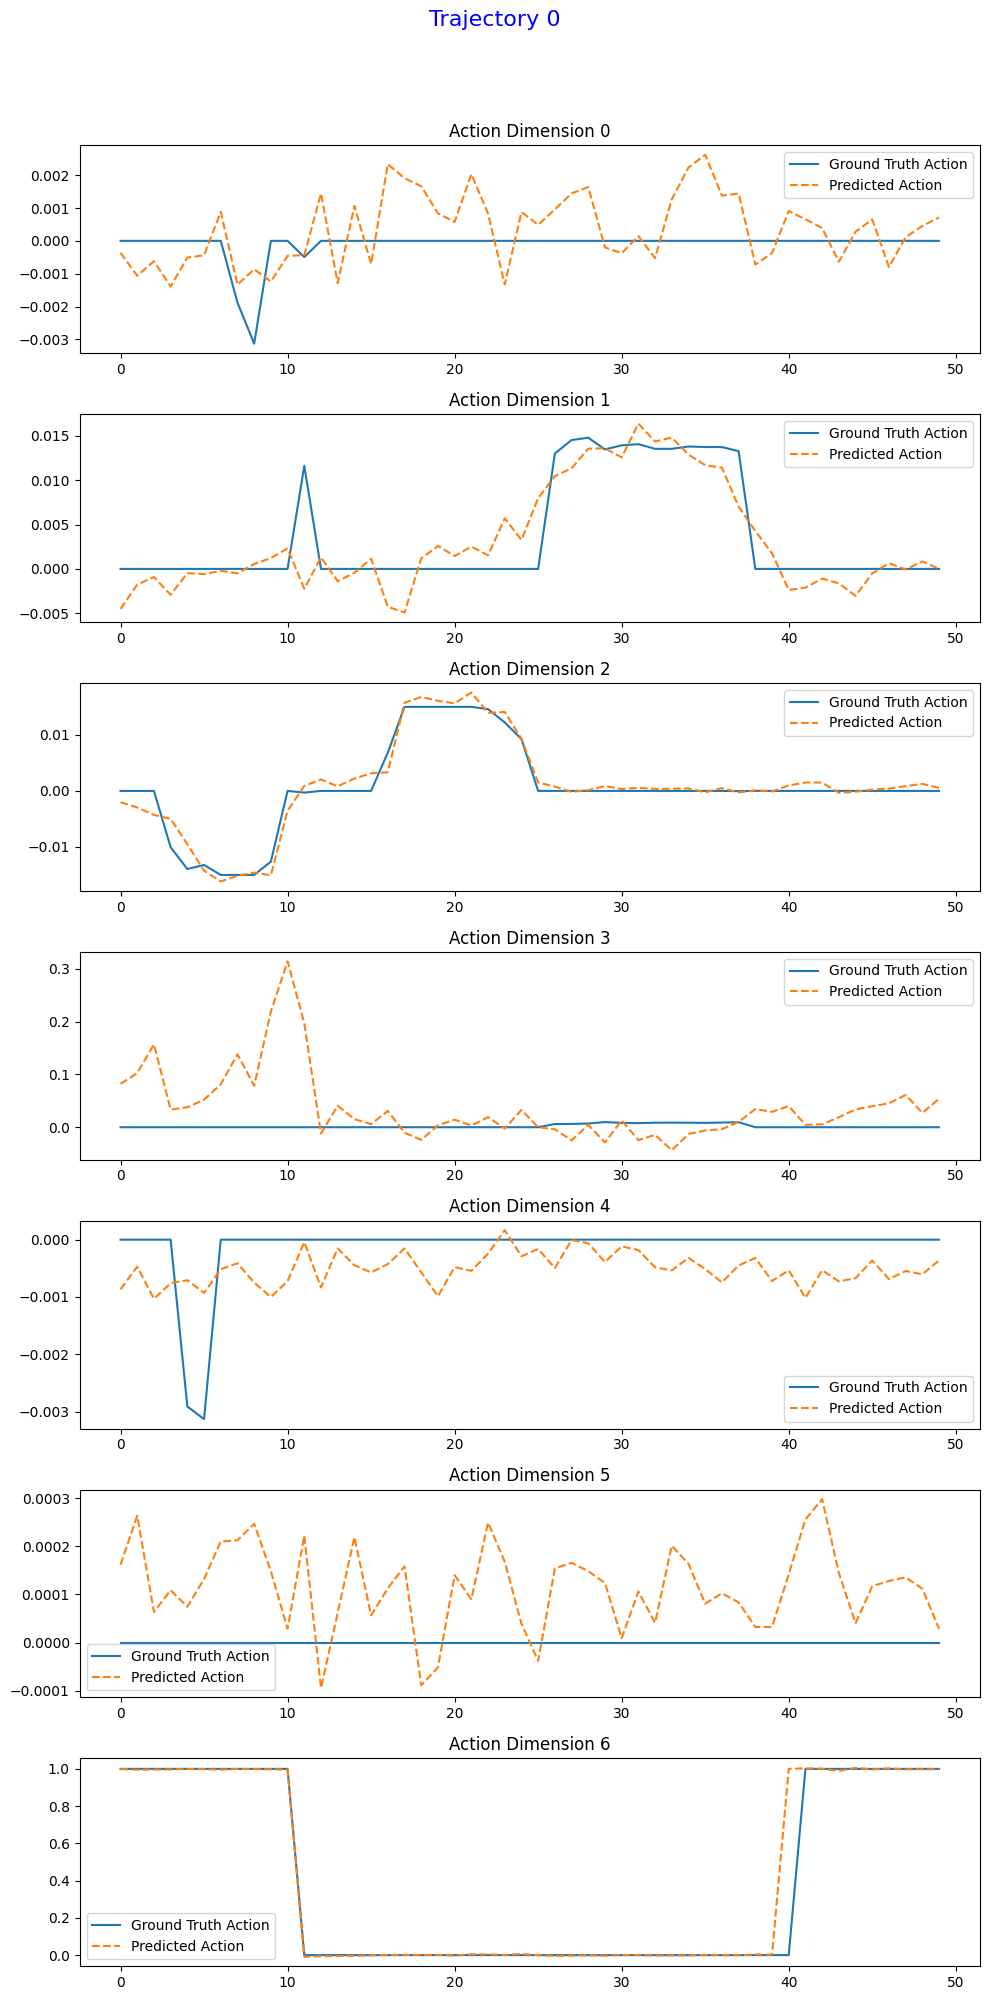

In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '7'
import numpy as np
import matplotlib.pyplot as plt

from openpi.models import model as _model
from openpi.policies import franka_policy
from openpi.policies import policy_config as _policy_config
from openpi.shared import download
from openpi.training import config as _config
from openpi.training import data_loader as _data_loader
from utils import calc_mse_and_check_via_single_trajectory


# We use s3 instead of gs
# CUDA_VISIBLE_DEVICES=7 uv run examples/franka/inference_test.py
checkpoint_dir = "/nvme_data/bingwen/Documents/arm_ws/openpi/checkpoints/pi0_franka/bingwen_thu/29999"
config = _config.get_config("pi0_franka")

# Create a trained policy.
policy = _policy_config.create_trained_policy(config, checkpoint_dir)


# Run the comparison for a single trajectory
calc_mse_and_check_via_single_trajectory(policy, config, plot=True)

# Delete the policy to free up memory.
del policy

